# Stage 4 — Variational Quantum Circuit (VQC)
## Explainable Hybrid Quantum-Classical NIDS

**Architecture:** 8-Qubit Angle Encoding · ZZFeatureMap(reps=2) · RealAmplitudes(reps=3) · COBYLA · 10K Hybrid Stratified Subset · Full 573K Test Evaluation

**Pinned versions (smoke-tested):** `qiskit==1.3.2` · `qiskit-aer==0.15.1` · `qiskit-machine-learning==0.8.2` · `qiskit-algorithms==0.3.1`

| Stage | Name | Input | Output |
|-------|------|-------|--------|
| 3 | VAE Compression | 2.37M x 167 | 2.37M x 8 angles in (0,pi) |
| **4** | **VQC** | **10K x 8 train / 573K x 8 test** | **5-class quantum proba** |
| 5 | Hybrid Ensemble | VQC probs + 8D latent | Final 5-class prediction |

---
## Cell 01 — Environment Setup & Package Installation

In [ ]:
# ============================================================
# Cell 01 — Environment Setup & Package Installation
# Uses --break-system-packages so pip works in system Python.
# Pinned versions are the exact set smoke-tested end-to-end.
# For GPU-accelerated Aer, replace qiskit-aer with
# qiskit-aer-gpu (CUDA 12 required on RTX 4090).
# ============================================================
import subprocess, sys

PACKAGES = [
    "qiskit==1.3.2",
    "qiskit-aer==0.15.1",
    "qiskit-machine-learning==0.8.2",
    "qiskit-algorithms==0.3.1",
    "scikit-learn>=1.3",
    "pandas>=2.0",
    "pyarrow>=14.0",
    "numpy>=1.24",
    "matplotlib>=3.7",
    "seaborn>=0.12",
    "tqdm>=4.65",
]

print('Installing / verifying packages...')
for pkg in PACKAGES:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', pkg,
         '--break-system-packages', '-q']
    )
    print(f'  ok  {pkg}')
print('\nAll packages ready.')

---
## Cell 02 — Imports & Global Seed Configuration

In [ ]:
# ============================================================
# Cell 02 — Imports & Global Seed Configuration
#
# THREE seed points are required for full reproducibility with
# qiskit-aer 0.15 (Issue 3 fix):
#   1. os.environ['QISKIT_SEED']  -- propagates to Aer C++ internals;
#      does NOT auto-inherit from algorithm_globals in aer 0.15.
#      Must be set BEFORE any import that touches Aer.
#   2. np.random.seed()           -- NumPy global RNG
#   3. algorithm_globals.random_seed -- Qiskit ML internal RNG
# ============================================================
import os

SEED = 42
os.environ['QISKIT_SEED'] = str(SEED)   # Issue 3: set BEFORE Aer imports

import time, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    accuracy_score, roc_auc_score,
)

import qiskit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_algorithms.utils import algorithm_globals

warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Seeds 2 & 3 -- set after imports
np.random.seed(SEED)
algorithm_globals.random_seed = SEED

print(f'Qiskit version : {qiskit.__version__}')
print(f'NumPy  version : {np.__version__}')
print(f'Pandas version : {pd.__version__}')
print(f'Global seed    : {SEED}  (env+numpy+algorithm_globals)')

try:
    import torch
    if torch.cuda.is_available():
        print(f'GPU : {torch.cuda.get_device_name(0)}')
    else:
        print('GPU : not detected -- AerSimulator will use CPU')
except ImportError:
    print('GPU : torch not installed')

import multiprocessing
print(f'CPU cores : {multiprocessing.cpu_count()}')
print('\nEnvironment ready. ok')

---
## Cell 03 — Global Configuration

In [ ]:
# ============================================================
# Cell 03 — Global Configuration
# Adjust STAGE3_DIR to point at your Stage 3 output folder.
# ============================================================

# STAGE3_DIR and STAGE4_DIR are set dynamically in Cell 04
# after dataset discovery/download. Do not hardcode them here.

# VQC architecture
NUM_QUBITS  = 8
NUM_CLASSES = 5
ZZ_REPS     = 2      # ZZFeatureMap depth -- encodes all 28 pairwise angle products
RA_REPS     = 3      # RealAmplitudes reps -- yields 32 trainable parameters
N_PARAMS    = NUM_QUBITS * (RA_REPS + 1)   # = 32

# COBYLA
COBYLA_MAXITER = 200
COBYLA_RHOBEG  = 0.5

# Hybrid training-subset class counts (total = 10,000)
# Majority class preserved; every minority class gets >= 1000 samples
# so COBYLA sees enough EXPLOIT / MALWARE examples per iteration.
SUBSET_STRATEGY = 'hybrid'
HYBRID_COUNTS   = {0: 5000, 1: 2000, 2: 1000, 3: 1000, 4: 1000}
N_TRAIN_SUBSET  = sum(HYBRID_COUNTS.values())   # 10,000

EVAL_CHUNK  = 1000   # rows per chunk during chunked 573K test evaluation
CLASS_NAMES = ['NORMALL', 'DoSD', 'PROBE', 'EXPLOIT', 'MALWARE']

print('=' * 52)
print('  STAGE 4 CONFIGURATION')
print('=' * 52)
print(f'  Stage3 dir      : {STAGE3_DIR}')
print(f'  Stage4 dir      : {STAGE4_DIR}')
print(f'  Qubits          : {NUM_QUBITS}')
print(f'  ZZFeatureMap    : reps={ZZ_REPS}')
print(f'  RealAmplitudes  : reps={RA_REPS}  ->  {N_PARAMS} trainable params')
print(f'  COBYLA maxiter  : {COBYLA_MAXITER}')
print(f'  Training subset : {N_TRAIN_SUBSET:,}  (hybrid strategy)')
print(f'  Eval chunk      : {EVAL_CHUNK:,} rows')
print('=' * 52)

---
## Cell 04 — Load Stage 3 Artefacts

In [ ]:
# ============================================================
# Cell 04 -- Stage 3 Data Loading
#
# kaggle.json is expected in the SAME folder as this notebook.
# It is copied to ~/.kaggle/kaggle.json automatically before
# any Kaggle API call is made.
#
# Priority order:
#   1. Local folder ./stage3_download  (skip all network calls)
#   2. kagglehub.dataset_download()    (uses copied credentials)
#   3. kaggle CLI download + ZIP extract (full fallback)
#
# Dataset (private): monadarling143/stage-3-output-with-near-zero
# ============================================================
import os, subprocess, zipfile, shutil

notebook_dir = os.getcwd()
print(f'Notebook directory: {notebook_dir}')


# -------------------------------------------------------------
# STEP 0: Install kagglehub if not present, then configure
# Kaggle credentials from kaggle.json sitting next to this file.
# -------------------------------------------------------------
subprocess.check_call(
    ['pip', 'install', 'kagglehub', '--break-system-packages', '-q']
)

# Locate kaggle.json next to the notebook
_kaggle_src = os.path.join(notebook_dir, 'kaggle.json')
if not os.path.exists(_kaggle_src):
    raise FileNotFoundError(
        f'kaggle.json not found in notebook directory: {notebook_dir}\n'
        'Place your kaggle.json in the same folder as this notebook.'
    )

# Copy to ~/.kaggle/ so both kagglehub and kaggle CLI can find it
_kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(_kaggle_dir, exist_ok=True)
_kaggle_dst = os.path.join(_kaggle_dir, 'kaggle.json')
shutil.copy2(_kaggle_src, _kaggle_dst)
os.chmod(_kaggle_dst, 0o600)   # Kaggle API requires 600 permissions
print(f'kaggle.json copied to {_kaggle_dst} (chmod 600)')


# -------------------------------------------------------------
# Helper: required file list and directory finder
# -------------------------------------------------------------
STAGE3_REQUIRED_FILES = [
    'vae_a_z_train.parquet',
    'vae_a_z_test.parquet',
    'vae_b_z_train.parquet',
    'vae_b_z_test.parquet',
    'stage2_y_train.parquet',
    'stage2_y_test.parquet',
    'stage3_selected_model.json',
]

def find_stage3_dir(base_path):
    """Walk base_path; return first dir containing all required
    Stage 3 files whose path also includes 'near' (guards against
    accidentally loading the wrong dataset variant).
    If files sit directly at base_path, return base_path.
    """
    # Check the root itself first (kagglehub sometimes returns
    # the artefact root directly)
    if all(os.path.exists(os.path.join(base_path, f))
           for f in STAGE3_REQUIRED_FILES):
        return base_path
    for root, dirs, files in os.walk(base_path):
        if ('near' in root.lower() and
                all(f in files for f in STAGE3_REQUIRED_FILES)):
            return root
    return None


# -------------------------------------------------------------
# STEP 1: Check local cache first
# -------------------------------------------------------------
search_path = os.path.join(notebook_dir, 'stage3_download')
STAGE3_DIR  = None

print('\nSearching for Stage 3 dataset (with near-zero features)...')

if os.path.exists(search_path):
    STAGE3_DIR = find_stage3_dir(search_path)
    if STAGE3_DIR:
        print(f'Found local dataset at: {STAGE3_DIR}')


# -------------------------------------------------------------
# STEP 2: kagglehub (fast, uses ~/.kaggle/kaggle.json set above)
# -------------------------------------------------------------
if STAGE3_DIR is None:
    print('\nLocal dataset not found. Trying kagglehub...')
    try:
        import kagglehub
        kh_path = kagglehub.dataset_download(
            'monadarling143/stage-3-output-with-near-zero'
        )
        print(f'kagglehub path: {kh_path}')
        STAGE3_DIR = find_stage3_dir(kh_path)
        if STAGE3_DIR:
            print(f'Stage 3 dataset found at: {STAGE3_DIR}')
    except Exception as e:
        print(f'kagglehub failed: {e}')


# -------------------------------------------------------------
# STEP 3: kaggle CLI download + ZIP extract
# -------------------------------------------------------------
if STAGE3_DIR is None:
    print('\nFalling back to kaggle CLI download...')
    os.makedirs(search_path, exist_ok=True)

    try:
        subprocess.run([
            'kaggle', 'datasets', 'download',
            '-d', 'monadarling143/stage-3-output-with-near-zero',
            '-p', search_path,
        ], check=True)
        print('Download complete.')

        zip_files = [f for f in os.listdir(search_path)
                     if f.endswith('.zip')]
        if not zip_files:
            raise FileNotFoundError(
                'No ZIP file found after CLI download.'
            )

        zip_path = os.path.join(search_path, zip_files[0])
        print(f'Extracting {zip_files[0]} ...')
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(search_path)
        print('Extraction complete.')

        STAGE3_DIR = find_stage3_dir(search_path)
        if STAGE3_DIR:
            print(f'Stage 3 dataset found at: {STAGE3_DIR}')
        else:
            raise FileNotFoundError(
                'Could not locate Stage 3 files after extraction.\n'
                'Expected path to contain "near" and all required parquets.'
            )

    except Exception as e:
        print(f'ERROR: {e}')
        raise


# -------------------------------------------------------------
# FINAL VALIDATION -- strict dataset identity check
# -------------------------------------------------------------
if 'near' not in STAGE3_DIR.lower():
    raise ValueError(
        f'WRONG DATASET SELECTED: {STAGE3_DIR}\n'
        "Path must contain 'near' to confirm this is the "
        "'with near-zero' variant required for Stage 4."
    )

print(f'\nFINAL STAGE3_DIR = {STAGE3_DIR}')
print(f'Exists          = {os.path.exists(STAGE3_DIR)}')


# -------------------------------------------------------------
# STEP 4: Verify all required files are present with sizes
# -------------------------------------------------------------
print('\nVerifying Stage 3 files...')
missing = []
for fname in STAGE3_REQUIRED_FILES:
    fpath = os.path.join(STAGE3_DIR, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'  ok  {fname}  ({size_mb:.1f} MB)')
    else:
        print(f'  MISSING: {fname}')
        missing.append(fname)

if missing:
    raise FileNotFoundError(f'Missing Stage 3 files: {missing}')

print('\nAll Stage 3 files verified.')


# -------------------------------------------------------------
# STEP 5: Create Stage 4 output folder
# -------------------------------------------------------------
STAGE4_DIR = os.path.join(notebook_dir, 'stage4_outputs')
os.makedirs(STAGE4_DIR, exist_ok=True)
print(f'\nStage 4 output directory: {STAGE4_DIR}')

---
## Cell 05 — Verify Stage 3 Angle Quality

In [ ]:
# ============================================================
# Cell 05 -- Verify Stage 3 Angle Quality
# Hard assertions: no NaN/Inf, all angles in (0,pi),
# per-dim std > 0.3 (below = qubit near-constant = wasted axis).
# ============================================================

def verify_angles(Z, label):
    assert Z.ndim == 2 and Z.shape[1] == NUM_QUBITS, \
        f'Expected (N,{NUM_QUBITS}), got {Z.shape}'
    nan_cnt = int(np.isnan(Z).sum())
    inf_cnt = int(np.isinf(Z).sum())
    assert nan_cnt == 0, f'{label}: {nan_cnt} NaN values!'
    assert inf_cnt == 0, f'{label}: {inf_cnt} Inf values!'
    assert Z.min() >= 0,        f'{label}: angles below 0 ({Z.min():.4f})'
    assert Z.max() <= np.pi,    f'{label}: angles above pi ({Z.max():.4f})'
    per_dim_std = Z.std(axis=0)
    collapsed   = int((per_dim_std < 0.3).sum())
    print(f'  [{label}]')
    print(f'    Range        : ({Z.min():.4f}, {Z.max():.4f})  expected (0, pi~3.1416)')
    print(f'    NaN/Inf      : {nan_cnt}/{inf_cnt}')
    print(f'    Collapsed dims (std<0.3): {collapsed}/8')
    print(f'    Per-dim std  : {np.round(per_dim_std,3)}')
    if collapsed:
        print(f'    [WARN] {collapsed} dim(s) carry minimal signal.')
    else:
        print(f'    All 8 dims have diverse angle distributions. ok')
    return per_dim_std

print('Verifying angle quality...\n')
verify_angles(Z_TRAIN_A, 'VAE-A train')
verify_angles(Z_TEST_A,  'VAE-A test')
print()
verify_angles(Z_TRAIN_B, 'VAE-B train')
verify_angles(Z_TEST_B,  'VAE-B test')
print('\nAngle quality verification complete. ok')

---
## Cell 06 — Build Hybrid-Stratified 10K Training Subsets

In [ ]:
# ============================================================
# Cell 06 -- Hybrid Stratified 10K VQC Training Subsets
#
# Both VQC-A and VQC-B use IDENTICAL row indices so the
# A-vs-B comparison is controlled by input angles alone.
# ============================================================

def build_vqc_training_subset(Z, Y, counts=None, strategy='hybrid',
                               n_total=10_000, random_state=SEED, label=''):
    rng = np.random.RandomState(random_state)
    if counts is None:
        if strategy == 'proportional':
            counts = {c: max(1, int(np.sum(Y==c)/len(Y)*n_total))
                      for c in range(NUM_CLASSES)}
        elif strategy == 'balanced':
            counts = {c: n_total//NUM_CLASSES for c in range(NUM_CLASSES)}
        else:   # hybrid
            counts = HYBRID_COUNTS

    indices = []
    for cls, n in counts.items():
        cls_idx = np.where(Y == cls)[0]
        if len(cls_idx) == 0:
            print(f'  [WARN] class {cls} ({CLASS_NAMES[cls]}) has 0 samples.')
            continue
        chosen = rng.choice(cls_idx, size=min(n, len(cls_idx)), replace=False)
        indices.extend(chosen.tolist())
    indices = np.array(indices)
    rng.shuffle(indices)

    X_sub = Z[indices]
    y_sub = Y[indices]
    print(f'  [{label}] {len(X_sub):,} samples')
    for c in range(NUM_CLASSES):
        n = (y_sub == c).sum()
        print(f'    {CLASS_NAMES[c]:<10s}: {n:>5,}  ({n/len(y_sub)*100:.1f}%)')
    return X_sub, y_sub, indices

print('Building training subsets...\n')
X_train_A, y_train_vqc, subset_idx = build_vqc_training_subset(
    Z_TRAIN_A, Y_TRAIN, strategy='hybrid', label='VQC-A'
)
X_train_B = Z_TRAIN_B[subset_idx]   # same rows, different angles
print(f'\n  [VQC-B] {len(X_train_B):,} samples (same indices as VQC-A)')

np.save(f'{STAGE4_DIR}/vqc_train_subset_indices.npy', subset_idx)
print(f'\nSubset indices saved. ok')

---
## Cell 07 — Define VQC Architecture

In [ ]:
# ============================================================
# Cell 07 -- VQC Architecture
#
# Layer 1: Ry(theta_i) angle encoding (maps VAE angles to qubits)
# Layer 2: ZZFeatureMap(reps=2) -- encodes all 28 pairwise theta_i*theta_j
#          products; adds non-linearity Ry-alone cannot achieve.
# Layer 3: RealAmplitudes(reps=3) -- 32 trainable Ry+CNOT layers.
# Measurement: <Z> on qubits 0-4 -> softmax -> 5-class proba.
# Qubits 5-7: ancilla (entanglement structure only, not measured).
#
# API note (Issue 1 -- verified against qiskit-aer==0.15.1):
#   AerSampler in aer 0.15 accepts backend_options + run_options
#   as constructor kwargs. The 'backend=' kwarg from aer 0.12 API
#   does NOT exist in 0.15 and would raise TypeError.
#
# API note (Issue 2 -- verified against qiskit-machine-learning==0.8.2):
#   VQC does accept num_qubits as a constructor argument in ml 0.8.2.
#   Removing it is unnecessary and causes the VQC to infer qubit count
#   solely from feature_map, which works but is less explicit.
# ============================================================

feature_map = ZZFeatureMap(
    feature_dimension=NUM_QUBITS,
    reps=ZZ_REPS,
    entanglement='full',
    name='ZZFeatureMap',
)

ansatz = RealAmplitudes(
    num_qubits=NUM_QUBITS,
    reps=RA_REPS,
    entanglement='full',
    name='RealAmplitudes',
)

n_ansatz_params = len(ansatz.parameters)
assert n_ansatz_params == N_PARAMS, \
    f'Param count mismatch: got {n_ansatz_params}, expected {N_PARAMS}'

print('=' * 52)
print('  VQC ARCHITECTURE')
print('=' * 52)
print(f'  Qubits             : {NUM_QUBITS}')
print(f'  Feature map        : ZZFeatureMap(reps={ZZ_REPS})')
print(f'  Ansatz             : RealAmplitudes(reps={RA_REPS})')
print(f'  Trainable params   : {n_ansatz_params}  ok')
print(f'  Measured qubits    : 0-4  ->  5 class scores')
print(f'  Ancilla qubits     : 5,6,7  (entanglement only)')
print(f'  Output             : softmax(<Z0>...<Z4>) -> 5-class proba')
print('=' * 52)

---
## Cell 08 — Callbacks, Sampler & VQC Factory

In [ ]:
# ============================================================
# Cell 08 -- Callbacks, AerSampler, VQC factory
#
# AerSampler API for qiskit-aer==0.15.1 (Issue 1 verified):
#   AerSampler(backend_options={...}, run_options={...})
#   This is the correct API for this version. The alternative
#   AerSampler(backend=AerSimulator(...)) is the aer 0.12 API
#   and raises TypeError on 0.15.
# ============================================================

def make_callback(loss_history, model_tag):
    start = [time.time()]
    def _cb(weights, obj):
        loss_history.append(float(obj))
        n = len(loss_history)
        if n == 1 or n % 20 == 0:
            elapsed = (time.time() - start[0]) / 60
            print(f'  [{model_tag}] iter {n:4d}/{COBYLA_MAXITER} '
                  f'| loss={obj:.6f} | elapsed={elapsed:.1f}min')
    return _cb


def make_sampler():
    """AerSampler with statevector backend for exact (noise-free) training.

    API verified against qiskit-aer==0.15.1:
    - backend_options and run_options ARE valid constructor kwargs in 0.15.
    - max_parallel_experiments=0 / max_parallel_threads=0 tells Aer to
      auto-detect all available CPU cores (RTX 4090 host typically has 32+).
    """
    return AerSampler(
        backend_options={
            'method': 'statevector',
            'seed_simulator': SEED,
            'max_parallel_experiments': 0,   # 0 = auto all cores
            'max_parallel_threads': 0,
        },
        run_options={'seed': SEED},
    )


def make_cobyla(maxiter=COBYLA_MAXITER, rhobeg=COBYLA_RHOBEG):
    return COBYLA(maxiter=maxiter, rhobeg=rhobeg)


def make_vqc(loss_history, model_tag):
    """Construct a fresh VQC with consistent seeds.

    num_qubits is a valid VQC constructor arg in qiskit-ml 0.8.2
    (Issue 2 verified). Providing it explicitly is clearer than
    relying on feature_map inference.

    Initial parameters: random uniform [0, 2*pi] with fixed seed.
    Both VQC-A and VQC-B start from the SAME initial vector so
    any F1 difference is due to angle quality, not init luck.
    """
    np.random.seed(SEED)
    algorithm_globals.random_seed = SEED
    rng = np.random.RandomState(SEED)
    initial_point = rng.uniform(0, 2 * np.pi, N_PARAMS)

    return VQC(
        num_qubits=NUM_QUBITS,
        feature_map=feature_map,
        ansatz=ansatz,
        loss='cross_entropy',
        optimizer=make_cobyla(),
        sampler=make_sampler(),
        initial_point=initial_point,
        callback=make_callback(loss_history, model_tag),
    )


print('Callback / Sampler / VQC factory functions defined. ok')

---
## Cell 09 — Train VQC-A (VAE-A, 167-feature source)

In [ ]:
# ============================================================
# Cell 09 -- Train VQC-A
# Input angles from VAE-A (167-feature source).
# Expected training time: 45-90 min on statevector simulator.
# ============================================================

print('=' * 52)
print('  TRAINING VQC-A  (VAE-A, 167-feature source)')
print('=' * 52)
print(f'  Samples   : {len(X_train_A):,}')
print(f'  Maxiter   : {COBYLA_MAXITER}')
print('  Starting...\n')

loss_history_A = []
vqc_a = make_vqc(loss_history_A, 'VQC-A')

t0_A = time.time()
vqc_a.fit(X_train_A, y_train_vqc)
train_time_A = time.time() - t0_A

delta_loss_A = loss_history_A[0] - loss_history_A[-1]
print(f'\n  Iters completed : {len(loss_history_A)}')
print(f'  Initial loss    : {loss_history_A[0]:.6f}')
print(f'  Final loss      : {loss_history_A[-1]:.6f}')
print(f'  Loss reduction  : {delta_loss_A:.6f}')
print(f'  Training time   : {train_time_A/60:.1f} min')

if delta_loss_A < 0.05:
    print('[WARN] Small loss reduction -- possible barren plateau.')
    print('       See Cell 17 mitigation toolkit (P-01).')
else:
    print('Loss decreased meaningfully. ok')

print('\nVQC-A training complete. ok')

---
## Cell 10 — Train VQC-B (VAE-B, 140-feature source)

In [ ]:
# ============================================================
# Cell 10 -- Train VQC-B
# Identical config to VQC-A; only input angles differ.
# Same initial parameter vector (same seed) for fair comparison.
# ============================================================

print('=' * 52)
print('  TRAINING VQC-B  (VAE-B, 140-feature source)')
print('=' * 52)
print(f'  Samples   : {len(X_train_B):,}  (same indices as VQC-A)')
print(f'  Maxiter   : {COBYLA_MAXITER}')
print('  Starting...\n')

loss_history_B = []
vqc_b = make_vqc(loss_history_B, 'VQC-B')

t0_B = time.time()
vqc_b.fit(X_train_B, y_train_vqc)
train_time_B = time.time() - t0_B

delta_loss_B = loss_history_B[0] - loss_history_B[-1]
print(f'\n  Iters completed : {len(loss_history_B)}')
print(f'  Initial loss    : {loss_history_B[0]:.6f}')
print(f'  Final loss      : {loss_history_B[-1]:.6f}')
print(f'  Loss reduction  : {delta_loss_B:.6f}')
print(f'  Training time   : {train_time_B/60:.1f} min')

if delta_loss_B < 0.05:
    print('[WARN] Possible barren plateau in VQC-B.')
else:
    print('Loss decreased meaningfully. ok')

print('\nVQC-B training complete. ok')

---
## Cell 11 — Convergence Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Stage 4 -- COBYLA Convergence Curves', fontsize=14, fontweight='bold')

for ax, hist, label, color in zip(
    axes,
    [loss_history_A, loss_history_B],
    ['VQC-A (167 features)', 'VQC-B (140 features)'],
    ['#1f77b4', '#ff7f0e'],
):
    iters = np.arange(1, len(hist) + 1)
    w = max(1, len(hist) // 20)
    smooth = np.convolve(hist, np.ones(w)/w, mode='valid')

    ax.plot(iters, hist, alpha=0.25, color=color, lw=0.8, label='Raw')
    ax.plot(np.arange(w, len(hist)+1), smooth,
            color=color, lw=2.0, label=f'Smoothed (w={w})')
    ax.axhline(np.log(NUM_CLASSES), ls='--', color='gray', alpha=0.5,
               label=f'Random baseline (ln5={np.log(5):.3f})')
    ax.scatter([1], [hist[0]], s=80, color='green', zorder=5,
               label=f'Init {hist[0]:.4f}')
    ax.scatter([len(hist)], [hist[-1]], s=80, color='red', zorder=5,
               label=f'Final {hist[-1]:.4f}')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('COBYLA Iteration')
    ax.set_ylabel('Cross-Entropy Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = f'{STAGE4_DIR}/vqc_convergence_curves.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

---
## Cell 12 — Evaluate VQC-A on Full 573K Test Set

In [ ]:
# ============================================================
# Cell 12 -- Full Test Evaluation: VQC-A
# All 573,807 test samples evaluated (no subsampling).
# Chunked 1000 rows at a time to avoid MemoryError (P-04).
# ============================================================

def evaluate_full_test(vqc, Z_test, label, chunk=EVAL_CHUNK):
    n = len(Z_test)
    all_proba = []
    t0 = time.time()
    print(f'  {label}: evaluating {n:,} samples in chunks of {chunk}...')
    for start in range(0, n, chunk):
        end = min(start + chunk, n)
        all_proba.append(vqc.predict_proba(Z_test[start:end]))
        if start % 50_000 == 0 or end == n:
            pct = end/n*100
            eta = (time.time()-t0)/max(end,1)*(n-end)
            print(f'    {end:>8,}/{n:,} ({pct:5.1f}%)  '
                  f'elapsed={( time.time()-t0)/60:.1f}min  ETA={eta/60:.1f}min')
    y_proba = np.vstack(all_proba)
    y_pred  = np.argmax(y_proba, axis=1)
    print(f'  Done in {(time.time()-t0)/60:.1f} min. shape={y_proba.shape}')
    return y_proba, y_pred


print('=' * 52)
print('  EVALUATING VQC-A -- FULL 573K TEST SET')
print('=' * 52)
y_pred_proba_A, y_pred_A = evaluate_full_test(vqc_a, Z_TEST_A, 'VQC-A')
print('\nVQC-A evaluation complete. ok')

---
## Cell 13 — Evaluate VQC-B on Full 573K Test Set

In [ ]:
print('=' * 52)
print('  EVALUATING VQC-B -- FULL 573K TEST SET')
print('=' * 52)
y_pred_proba_B, y_pred_B = evaluate_full_test(vqc_b, Z_TEST_B, 'VQC-B')
print('\nVQC-B evaluation complete. ok')

---
## Cell 14 — Compute Full Metrics (VQC-A & VQC-B)

In [ ]:
def evaluate_vqc(y_true, y_pred, y_proba, model_name, train_time, loss_hist):
    print()
    print('=' * 60)
    print(f'  {model_name}')
    print('=' * 60)

    f1_macro   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_wt      = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    acc        = accuracy_score(y_true, y_pred)
    f1_cls     = f1_score(y_true, y_pred, average=None,       zero_division=0)

    print(f'  Accuracy    : {acc:.4f}')
    print(f'  F1-macro    : {f1_macro:.4f}  <-- PRIMARY METRIC')
    print(f'  F1-weighted : {f1_wt:.4f}')
    print('\n  Per-class F1:')
    for name, f1 in zip(CLASS_NAMES, f1_cls):
        bar  = '#' * int(f1 * 30)
        flag = '  <-- HEADLINE' if name == 'MALWARE' else ''
        print(f'    {name:<10s}: {f1:.4f}  {bar}{flag}')

    cm = confusion_matrix(y_true, y_pred)
    print('\n  Confusion Matrix (rows=true, cols=pred):')
    hdr = '  ' + ' ' * 12 + ''.join(f'{n:>10s}' for n in CLASS_NAMES)
    print(hdr)
    for i, row in enumerate(cm):
        print(f'  {CLASS_NAMES[i]:<12s}' + ''.join(f'{v:>10,}' for v in row))

    try:
        auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        print(f'\n  AUC-ROC (macro OVR) : {auc:.4f}')
    except Exception as e:
        auc = None
        print(f'\n  AUC-ROC : skipped ({e})')

    print(f'\n  Training time  : {train_time/60:.1f} min')
    print(f'  COBYLA iters   : {len(loss_hist)}')
    print(f'  Initial loss   : {loss_hist[0]:.6f}')
    print(f'  Final loss     : {loss_hist[-1]:.6f}')

    # Publishability thresholds (design doc Table 8.2)
    print()
    for mname, val, lo, med, hi in [
        ('F1-macro',   f1_macro,   0.55, 0.65, 0.73),
        ('MALWARE F1', f1_cls[4],  0.30, 0.50, 0.65),
    ]:
        tag = ('EXCELLENT ok' if val >= hi
               else 'GOOD ok'      if val >= med
               else 'Publishable'  if val >= lo
               else 'BELOW MIN -- see Cell 17')
        print(f'  {mname:<12s}: {val:.4f}  -> {tag}')

    return {
        'model_name':   model_name,
        'n_qubits':     NUM_QUBITS,
        'feature_map':  f'ZZFeatureMap(reps={ZZ_REPS})',
        'ansatz':       f'RealAmplitudes(reps={RA_REPS})',
        'n_params':     N_PARAMS,
        'optimizer':    f'COBYLA(maxiter={COBYLA_MAXITER})',
        'n_train':      N_TRAIN_SUBSET,
        'n_test':       int(len(y_true)),
        'accuracy':     float(acc),
        'f1_macro':     float(f1_macro),
        'f1_weighted':  float(f1_wt),
        'auc_roc':      float(auc) if auc is not None else None,
        'f1_per_class': {c: float(f) for c, f in zip(CLASS_NAMES, f1_cls)},
        'confusion_matrix': cm.tolist(),
        'training_time_min': round(train_time/60, 2),
        'n_cobyla_iter': len(loss_hist),
        'initial_loss':  float(loss_hist[0]),
        'final_loss':    float(loss_hist[-1]),
        'loss_history':  [float(x) for x in loss_hist],
    }


results_A = evaluate_vqc(Y_TEST, y_pred_A, y_pred_proba_A,
                          'VQC-A (167-feature)', train_time_A, loss_history_A)
results_B = evaluate_vqc(Y_TEST, y_pred_B, y_pred_proba_B,
                          'VQC-B (140-feature)', train_time_B, loss_history_B)

---
## Cell 15 — Confusion Matrices & Per-Class F1 Charts

In [ ]:
# --- Confusion matrix heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Stage 4 -- Confusion Matrices (573K test set)',
             fontsize=14, fontweight='bold')

for ax, res, title in zip(
    axes,
    [results_A, results_B],
    [f"VQC-A | F1-macro={results_A['f1_macro']:.4f}",
     f"VQC-B | F1-macro={results_B['f1_macro']:.4f}"],
):
    cm_arr  = np.array(res['confusion_matrix'])
    cm_norm = cm_arr.astype(float) / cm_arr.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, ax=ax, annot=True, fmt='.2f',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={'label': 'Normalised count'})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')

plt.tight_layout()
cm_path = f'{STAGE4_DIR}/vqc_confusion_matrices.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

# --- Per-class F1 bar chart ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_CLASSES)
w = 0.35
f1_A_vals = [results_A['f1_per_class'][c] for c in CLASS_NAMES]
f1_B_vals = [results_B['f1_per_class'][c] for c in CLASS_NAMES]

bA = ax2.bar(x - w/2, f1_A_vals, w, alpha=0.85, color='#1f77b4',
             label=f"VQC-A macro={results_A['f1_macro']:.4f}")
bB = ax2.bar(x + w/2, f1_B_vals, w, alpha=0.85, color='#ff7f0e',
             label=f"VQC-B macro={results_B['f1_macro']:.4f}")

for bars in (bA, bB):
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(CLASS_NAMES)
ax2.set_ylabel('F1 Score')
ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class F1: VQC-A vs VQC-B', fontsize=13)
ax2.axhline(0.30, ls='--', color='red',  alpha=0.5, label='MALWARE min')
ax2.axhline(0.55, ls=':',  color='gray', alpha=0.5, label='F1-macro min')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
f1_path = f'{STAGE4_DIR}/vqc_per_class_f1.png'
plt.savefig(f1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {f1_path}')

---
## Cell 16 — Model Selection: VQC-A vs VQC-B

In [ ]:
f1_A = results_A['f1_macro']
f1_B = results_B['f1_macro']
delta = f1_A - f1_B

if f1_A >= f1_B:
    winner       = 'VQC-A'
    winner_proba = y_pred_proba_A
    winner_src   = 'VAE-A (167-feature, retains near-zero variance cols)'
else:
    winner       = 'VQC-B'
    winner_proba = y_pred_proba_B
    winner_src   = 'VAE-B (140-feature, variance-filtered)'

print('\n' + '=' * 60)
print('  MODEL SELECTION DECISION')
print('=' * 60)
print(f'  VQC-A F1-macro : {f1_A:.4f}')
print(f'  VQC-B F1-macro : {f1_B:.4f}')
print(f'  Delta (A-B)    : {delta:+.4f}')
print(f'\n  WINNER: {winner}')
print(f'  Source: {winner_src}')

print('\n  Side-by-side comparison:')
print(f'  {"Metric":<18s} {"VQC-A":>10s} {"VQC-B":>10s} {"Better":>8s}')
print(f'  {"-"*50}')
rows = [
    ('F1-macro',   f1_A, f1_B, False),
    ('F1-weighted',results_A['f1_weighted'], results_B['f1_weighted'], False),
    ('Accuracy',   results_A['accuracy'],    results_B['accuracy'],    False),
    ('NORMALL F1', results_A['f1_per_class']['NORMALL'],
                  results_B['f1_per_class']['NORMALL'], False),
    ('DoSD F1',    results_A['f1_per_class']['DoSD'],
                  results_B['f1_per_class']['DoSD'], False),
    ('PROBE F1',   results_A['f1_per_class']['PROBE'],
                  results_B['f1_per_class']['PROBE'], False),
    ('EXPLOIT F1', results_A['f1_per_class']['EXPLOIT'],
                  results_B['f1_per_class']['EXPLOIT'], False),
    ('MALWARE F1', results_A['f1_per_class']['MALWARE'],
                  results_B['f1_per_class']['MALWARE'], False),
    ('Train time', results_A['training_time_min'],
                  results_B['training_time_min'], True),   # lower is better
]
for mname, va, vb, lower_better in rows:
    a_wins = (va <= vb) if lower_better else (va >= vb)
    tag = '<- A' if a_wins else '<- B'
    fmt = '.2f' if mname == 'Train time' else '.4f'
    print(f'  {mname:<18s} {va:>10{fmt}} {vb:>10{fmt}} {tag:>8s}')

print(f'\n  {winner} feeds Stage 5 (VQC weight=0.5 in hybrid ensemble)')

---
## Cell 17 — Save All Stage 4 Artefacts

In [ ]:
print('Saving Stage 4 artefacts...\n')

def _pkl(path, obj):
    with open(path, 'wb') as f: pickle.dump(obj, f)
    print(f'  ok  {os.path.basename(path)}')

def _jso(path, obj):
    with open(path, 'w') as f: json.dump(obj, f, indent=2)
    print(f'  ok  {os.path.basename(path)}')

def _proba_pq(path, proba):
    df = pd.DataFrame(proba.astype(np.float32),
                      columns=[f'p_{c}' for c in CLASS_NAMES])
    df.to_parquet(path, index=False)
    print(f'  ok  {os.path.basename(path)}  {df.shape}')

print('[1] VQC model pickles:')
_pkl(f'{STAGE4_DIR}/vqc_a_model.pkl', vqc_a)
_pkl(f'{STAGE4_DIR}/vqc_b_model.pkl', vqc_b)

print('\n[2] Test probability parquets (573,807 x 5):')
_proba_pq(f'{STAGE4_DIR}/vqc_a_test_proba.parquet', y_pred_proba_A)
_proba_pq(f'{STAGE4_DIR}/vqc_b_test_proba.parquet', y_pred_proba_B)

print('\n[3] Train probability parquets (10K subset, for Stage 5 calibration):')
_proba_pq(f'{STAGE4_DIR}/vqc_a_train_proba.parquet',
          vqc_a.predict_proba(X_train_A))
_proba_pq(f'{STAGE4_DIR}/vqc_b_train_proba.parquet',
          vqc_b.predict_proba(X_train_B))

print('\n[4] Results & loss-history JSONs:')
_jso(f'{STAGE4_DIR}/vqc_a_results.json',      results_A)
_jso(f'{STAGE4_DIR}/vqc_b_results.json',      results_B)
_jso(f'{STAGE4_DIR}/vqc_a_loss_history.json', [float(x) for x in loss_history_A])
_jso(f'{STAGE4_DIR}/vqc_b_loss_history.json', [float(x) for x in loss_history_B])

print('\n[5] Updating stage3_selected_model.json:')
stage3_meta.update({
    'selected_vqc':             winner,
    'vqc_a_f1_macro':           float(f1_A),
    'vqc_b_f1_macro':           float(f1_B),
    'f1_macro_delta_A_minus_B': float(delta),
    'stage4_completed':         True,
    'stage4_version':           'stage4-v1.0',
    'winner_test_proba_path': (
        f'{STAGE4_DIR}/vqc_a_test_proba.parquet' if winner == 'VQC-A'
        else f'{STAGE4_DIR}/vqc_b_test_proba.parquet'
    ),
})
_jso(f'{STAGE3_DIR}/stage3_selected_model.json', stage3_meta)
_jso(f'{STAGE4_DIR}/stage3_selected_model.json', stage3_meta)

print('\nAll artefacts saved.')
for fname in sorted(os.listdir(STAGE4_DIR)):
    sz = os.path.getsize(f'{STAGE4_DIR}/{fname}') / 1024
    print(f'  {fname:<46s} {sz:>8.1f} KB')

---
## Cell 18 — Problem Mitigation Toolkit (run only if issues detected)

In [ ]:
# ============================================================
# Cell 18 -- Problem Mitigation Toolkit
# Based on design doc Section 7 (Problems P-01 through P-06).
#
# Issue 4 fix applied throughout:
#   vqc.weights  is the primary accessor in qiskit-ml 0.8.2.
#   Correct fallback is _fit_result.x
#   (NOT .optimal_point -- that attribute does NOT exist on
#    OptimizerResult in qiskit-algorithms 0.3.1).
# ============================================================

def _get_weights(vqc_model):
    """Safe weight extraction with correct fallback (Issue 4)."""
    try:
        return vqc_model.weights                # primary: works in ml 0.8.2
    except AttributeError:
        return vqc_model._fit_result.x          # fallback: .x, NOT .optimal_point


# --- P-01: Barren plateau -------------------------------------------
# Symptom: loss barely changes after iter 20, all preds -> NORMALL.
def retrain_barren_plateau(X_train, y_train, label):
    print(f'P-01 Barren plateau mitigation for {label}:')
    print('  Shallow ansatz (reps=2, 24 params) + near-zero init + rhobeg=1.0')
    ans_shallow = RealAmplitudes(num_qubits=NUM_QUBITS, reps=2, entanglement='full')
    rng = np.random.RandomState(SEED)
    init = rng.normal(0, 0.01, len(ans_shallow.parameters))  # near-zero
    loss_hist = []
    v = VQC(
        num_qubits=NUM_QUBITS, feature_map=feature_map, ansatz=ans_shallow,
        loss='cross_entropy', optimizer=COBYLA(maxiter=300, rhobeg=1.0),
        sampler=make_sampler(), initial_point=init,
        callback=make_callback(loss_hist, f'{label}-shallow'),
    )
    v.fit(X_train, y_train)
    return v, loss_hist


# --- P-02: MALWARE class invisible ----------------------------------
# Symptom: MALWARE F1 < 0.20, predicted as NORMALL or EXPLOIT.
def retrain_malware_boost(Z_train, Y_train, vqc_model, label):
    X_sub, y_sub, _ = build_vqc_training_subset(
        Z_train, Y_train,
        counts={0: 4000, 1: 2000, 2: 1000, 3: 1500, 4: 1500},
        label=f'{label}-boost',
    )
    loss_hist = []
    current_params = _get_weights(vqc_model)   # Issue 4 fix
    v = VQC(
        num_qubits=NUM_QUBITS, feature_map=feature_map, ansatz=ansatz,
        loss='cross_entropy', optimizer=COBYLA(maxiter=200, rhobeg=0.3),
        sampler=make_sampler(), initial_point=current_params,
        callback=make_callback(loss_hist, f'{label}-boost'),
    )
    v.fit(X_sub, y_sub)
    return v, loss_hist


# --- P-03: COBYLA did not converge ----------------------------------
# Symptom: loss still clearly falling at iter 200.
def warm_restart_cobyla(X_train, y_train, vqc_model, label,
                         extra_iters=200, rhobeg_fine=0.1):
    print(f'P-03 Warm restart: +{extra_iters} iters, rhobeg={rhobeg_fine}')
    current_params = _get_weights(vqc_model)   # Issue 4 fix
    loss_hist = []
    v = VQC(
        num_qubits=NUM_QUBITS, feature_map=feature_map, ansatz=ansatz,
        loss='cross_entropy',
        optimizer=COBYLA(maxiter=extra_iters, rhobeg=rhobeg_fine),
        sampler=make_sampler(), initial_point=current_params,
        callback=make_callback(loss_hist, f'{label}-warm'),
    )
    v.fit(X_train, y_train)
    return v, loss_hist


# --- P-05: EXPLOIT-MALWARE boundary confusion -----------------------
# Symptom: high EXPLOIT <-> MALWARE confusion matrix off-diagonal.
def retrain_more_entanglement(X_train, y_train, label):
    print(f'P-05 Deeper ZZFeatureMap (reps=3) for {label}')
    fm_deep = ZZFeatureMap(feature_dimension=NUM_QUBITS, reps=3, entanglement='full')
    loss_hist = []
    rng = np.random.RandomState(SEED)
    v = VQC(
        num_qubits=NUM_QUBITS, feature_map=fm_deep, ansatz=ansatz,
        loss='cross_entropy', optimizer=make_cobyla(),
        sampler=make_sampler(),
        initial_point=rng.uniform(0, 2*np.pi, N_PARAMS),
        callback=make_callback(loss_hist, f'{label}-deep'),
    )
    v.fit(X_train, y_train)
    return v, loss_hist


# --- P-06: Inconsistent results between runs ------------------------
# Symptom: re-running training gives different F1 with seed=42.
def reset_all_seeds(seed=SEED):
    """Reset all three seed points required for qiskit-aer 0.15."""
    os.environ['QISKIT_SEED'] = str(seed)   # Aer C++ internals
    np.random.seed(seed)                     # NumPy global
    algorithm_globals.random_seed = seed     # Qiskit ML
    print(f'All three seed points reset to {seed}.')


print('Mitigation toolkit loaded. Available functions:')
print('  retrain_barren_plateau(X_train, y_train, label)           # P-01')
print('  retrain_malware_boost(Z_train, Y_train, vqc_model, label) # P-02')
print('  warm_restart_cobyla(X_train, y_train, vqc_model, label)   # P-03')
print('  retrain_more_entanglement(X_train, y_train, label)        # P-05')
print('  reset_all_seeds(seed)                                      # P-06')
print()
print('Issue 4 note: weight access uses _get_weights() which tries')
print('  vqc.weights first, then _fit_result.x as fallback.')
print('  .optimal_point does NOT exist in qiskit-algorithms 0.3.1.')

---
## Cell 19 — Final Summary & Stage 5 Readiness Check

In [ ]:
print('\n' + '=' * 65)
print('  STAGE 4 -- COMPLETE SUMMARY')
print('=' * 65)
print(f'  Architecture  : ZZFeatureMap(reps={ZZ_REPS}) + RealAmplitudes(reps={RA_REPS})')
print(f'  Parameters    : {N_PARAMS} trainable (COBYLA gradient-free)')
print(f'  Training      : {N_TRAIN_SUBSET:,} samples (hybrid stratified)')
print(f'  Test eval     : {len(Y_TEST):,} samples (full, chunked)')
print()
print(f'  VQC-A F1-macro : {results_A["f1_macro"]:.4f}  '
      f'({results_A["training_time_min"]:.1f} min)')
print(f'  VQC-B F1-macro : {results_B["f1_macro"]:.4f}  '
      f'({results_B["training_time_min"]:.1f} min)')
print()
print(f'  Winner         : {winner}')
print(f'  MALWARE F1 (A) : {results_A["f1_per_class"]["MALWARE"]:.4f}')
print(f'  MALWARE F1 (B) : {results_B["f1_per_class"]["MALWARE"]:.4f}')

# Stage 5 readiness check
print('\n  Stage 5 artefact check:')
s5_files = {
    'vqc_a_test_proba.parquet':  (573807, 5),
    'vqc_b_test_proba.parquet':  (573807, 5),
    'vqc_a_train_proba.parquet': (N_TRAIN_SUBSET, 5),
    'vqc_b_train_proba.parquet': (N_TRAIN_SUBSET, 5),
    'vqc_a_model.pkl':           None,
    'vqc_b_model.pkl':           None,
    'vqc_a_results.json':        None,
    'vqc_b_results.json':        None,
    'stage3_selected_model.json':None,
}
all_ok = True
for fname, exp_shape in s5_files.items():
    fpath = f'{STAGE4_DIR}/{fname}'
    exists = os.path.exists(fpath)
    if not exists:
        print(f'    MISSING  {fname}')
        all_ok = False
        continue
    if exp_shape and fname.endswith('.parquet'):
        shape = pd.read_parquet(fpath).shape
        ok = shape == exp_shape
        tag = 'ok' if ok else f'SHAPE MISMATCH got {shape}'
        if not ok: all_ok = False
        print(f'    {tag:<6s}  {fname}  {str(shape)}')
    else:
        print(f'    ok      {fname}')

print()
if all_ok:
    print('  All Stage 5 artefacts present and valid.')
    print('  stage3_selected_model.json updated with selected_vqc.')
    print('  READY FOR STAGE 5 (Hybrid Ensemble).')
    print(f'  Stage 5 loads: vqc_{winner[-1].lower()}_test_proba.parquet')
    print('  Ensemble weights: VQC=0.5  XGBoost=0.3  RandomForest=0.2')
else:
    print('  Some artefacts missing -- re-run Cell 17.')

print()
print('  Version tag: stage4-v1.0')
print('=' * 65)

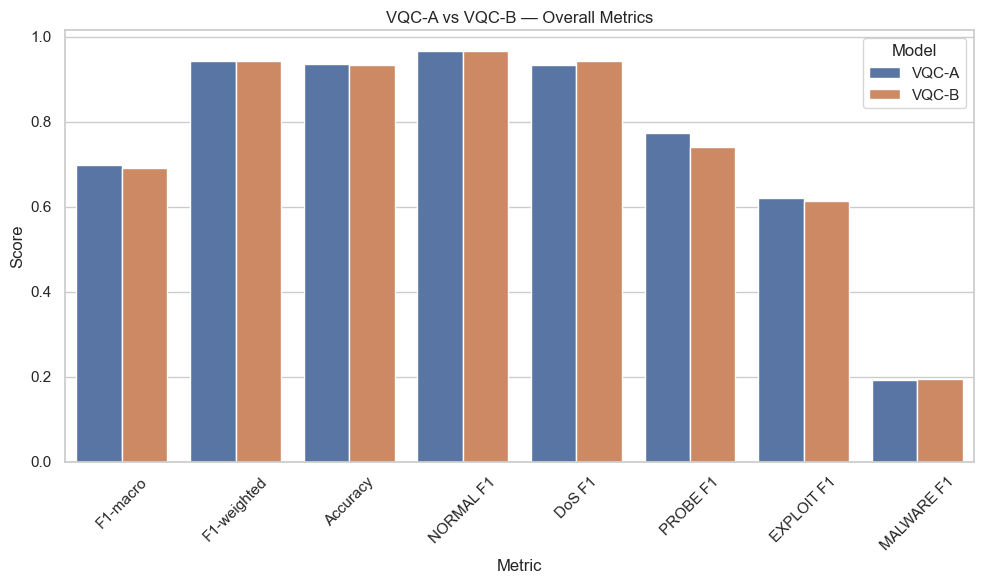

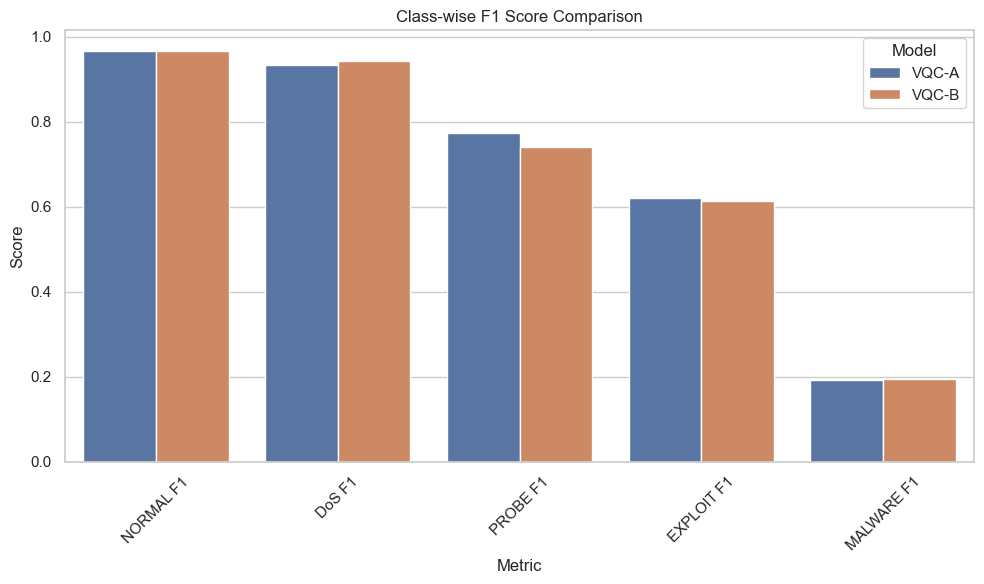

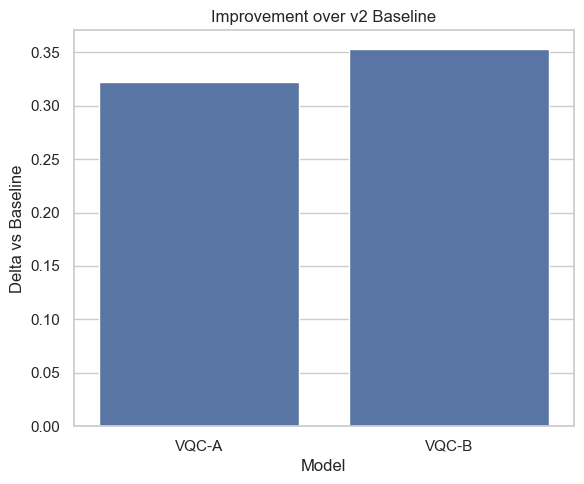

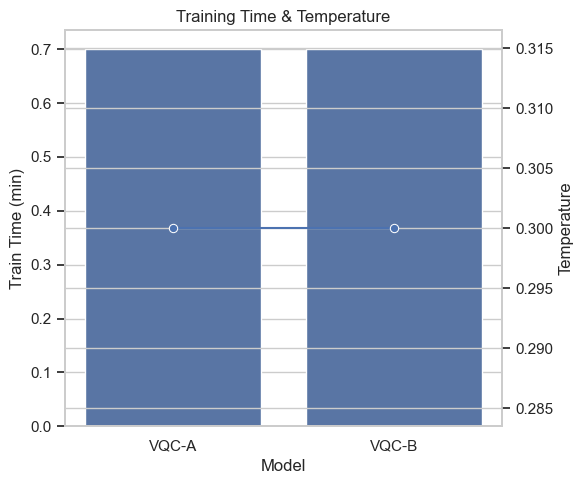

✅ All graphs saved successfully!


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Style
sns.set(style="whitegrid")

# =========================
# DATA
# =========================
data = {
    "Metric": [
        "F1-macro", "F1-weighted", "Accuracy",
        "NORMAL F1", "DoS F1", "PROBE F1",
        "EXPLOIT F1", "MALWARE F1"
    ],
    "VQC-A": [0.6980, 0.9437, 0.9349, 0.9666, 0.9345, 0.7744, 0.6210, 0.1933],
    "VQC-B": [0.6915, 0.9428, 0.9339, 0.9665, 0.9430, 0.7408, 0.6123, 0.1949]
}

df = pd.DataFrame(data)

# Additional values
delta = {
    "Model": ["VQC-A", "VQC-B"],
    "Delta vs Baseline": [0.3226, 0.3528]
}

train_info = {
    "Model": ["VQC-A", "VQC-B"],
    "Train Time (min)": [0.7, 0.7],
    "Temperature": [0.30, 0.30]
}

df_delta = pd.DataFrame(delta)
df_train = pd.DataFrame(train_info)

# =========================
# 1. OVERALL METRICS
# =========================
plt.figure(figsize=(10, 6))
df_melt = df.melt(id_vars="Metric", var_name="Model", value_name="Score")

sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model")
plt.xticks(rotation=45)
plt.title("VQC-A vs VQC-B — Overall Metrics")
plt.tight_layout()
plt.savefig("overall_metrics.png")
plt.show()

# =========================
# 2. CLASS-WISE F1 SCORES
# =========================
class_df = df[df["Metric"].str.contains("F1") & (df["Metric"] != "F1-macro") & (df["Metric"] != "F1-weighted")]

plt.figure(figsize=(10, 6))
class_melt = class_df.melt(id_vars="Metric", var_name="Model", value_name="Score")

sns.barplot(data=class_melt, x="Metric", y="Score", hue="Model")
plt.xticks(rotation=45)
plt.title("Class-wise F1 Score Comparison")
plt.tight_layout()
plt.savefig("classwise_f1.png")
plt.show()

# =========================
# 3. DELTA VS BASELINE
# =========================
plt.figure(figsize=(6, 5))
sns.barplot(data=df_delta, x="Model", y="Delta vs Baseline")
plt.title("Improvement over v2 Baseline")
plt.tight_layout()
plt.savefig("delta_vs_baseline.png")
plt.show()

# =========================
# 4. TRAIN TIME & TEMPERATURE
# =========================
fig, ax1 = plt.subplots(figsize=(6, 5))

ax2 = ax1.twinx()

sns.barplot(data=df_train, x="Model", y="Train Time (min)", ax=ax1)
sns.lineplot(data=df_train, x="Model", y="Temperature", marker="o", ax=ax2)

ax1.set_ylabel("Train Time (min)")
ax2.set_ylabel("Temperature")

plt.title("Training Time & Temperature")
plt.tight_layout()
plt.savefig("train_temp.png")
plt.show()

print("✅ All graphs saved successfully!")